<a href="https://colab.research.google.com/github/nikamsudarshan/handwritten_digit_recognizer/blob/main/Handwritten_Digit_Recognizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load the MNIST dataset
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


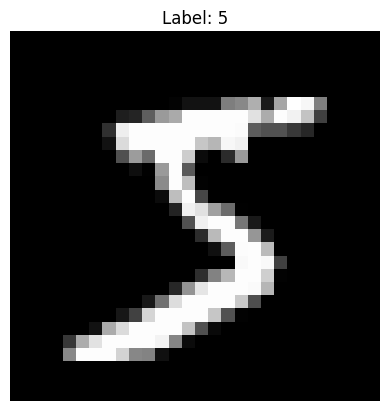

In [10]:
# Scale the pixel values to a range between 0 and 1
X_train, X_test = X_train / 255.0, X_test / 255.0

# Optional: Visualize the first image in the dataset to verify
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()

In [3]:
# Define the neural network architecture
model = models.Sequential([
    # Flatten 28x28 images to a 1D array of 784 pixels
    layers.Flatten(input_shape=(28, 28)),

    # Hidden layer with 128 neurons and ReLU activation
    layers.Dense(128, activation='relu'),

    # Dropout layer to prevent overfitting (randomly disables 20% of neurons)
    layers.Dropout(0.2),

    # Output layer with 10 neurons (for digits 0-9) and Softmax for probabilities
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=5, validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9083 - loss: 0.3145 - val_accuracy: 0.9672 - val_loss: 0.1176
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9560 - loss: 0.1496 - val_accuracy: 0.9733 - val_loss: 0.0918
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9657 - loss: 0.1130 - val_accuracy: 0.9757 - val_loss: 0.0784
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9717 - loss: 0.0916 - val_accuracy: 0.9765 - val_loss: 0.0784
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9746 - loss: 0.0794 - val_accuracy: 0.9803 - val_loss: 0.0680


313/313 - 1s - 2ms/step - accuracy: 0.9783 - loss: 0.0742

Test Accuracy: 97.83%


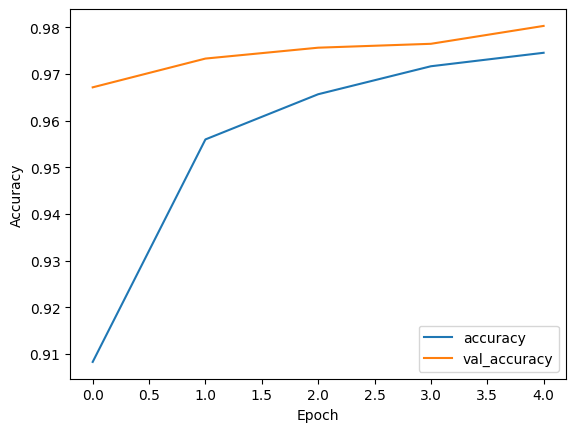

In [5]:
# Evaluate against the test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# Plot training vs validation accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

In [8]:
import gradio as gr
import numpy as np
import cv2

def classify_digit(image):
    """
    Preprocesses the drawn image to match the MNIST dataset distribution
    and passes it to the trained model for inference.
    """
    # 1. Extract the image array from the Gradio canvas
    img = image["composite"]

    # 2. Convert from RGBA to Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGBA2GRAY)

    # 3. Invert colors (MNIST is trained on white digits over a black background)
    gray = cv2.bitwise_not(gray)

    # 4. Auto-cropping (Bounding Box)
    # Locate the drawn digit and crop out the empty space to center the digit
    coords = cv2.findNonZero(gray)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        digit_crop = gray[y:y+h, x:x+w]

        # Add symmetric padding to maintain aspect ratio and mimic MNIST framing
        padding = max(w, h) // 4
        gray = cv2.copyMakeBorder(digit_crop, padding, padding, padding, padding,
                                  cv2.BORDER_CONSTANT, value=0)

    # 5. Downscale to the 28x28 resolution expected by the model
    resized = cv2.resize(gray, (28, 28), interpolation=cv2.INTER_AREA)

    # 6. Apply thresholding to sharpen edges lost during downscaling
    _, resized = cv2.threshold(resized, 100, 255, cv2.THRESH_BINARY)

    # 7. Normalize pixel values to [0, 1] and reshape for model input
    normalized = resized / 255.0
    reshaped = normalized.reshape(1, 28, 28)

    # 8. Model Inference
    prediction = model.predict(reshaped)
    predicted_digit = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    return f"Predicted Digit: {predicted_digit} (Confidence: {confidence:.2f}%)"

# Configure the UI Interface
interface = gr.Interface(
    fn=classify_digit,
    inputs=gr.Sketchpad(
        type="numpy",
        crop_size=(280, 280),
        brush=gr.Brush(default_size=15) # Thick brush prevents strokes from blurring out on resize
    ),
    outputs="text",
    title="Handwritten Digit Recognizer",
    description="Draw a single number from 0 to 9 on the canvas below and click Submit to test the model."
)

# Launch the interactive web app within the notebook
interface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://67c56480fb8f9ace7c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://67c56480fb8f9ace7c.gradio.live
